## Dataset Import

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\miche\.cache\kagglehub\datasets\mohamedamineferrag\edgeiiotset-cyber-security-dataset-of-iot-iiot\versions\5


In [4]:
import pandas as pd
df = pd.read_csv(path+'/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv', low_memory=False)

## Dataset Analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  str    
 1   ip.src_host                157800 non-null  str    
 2   ip.dst_host                157800 non-null  str    
 3   arp.dst.proto_ipv4         157800 non-null  str    
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  str    
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   icmp.transmit_timestamp    157800 non-null  float64
 10  icmp.unused                157800 non-null  float64
 11  http.file_data             157800 non-null  str    
 12  http.content_length        157800 non-null  float64
 13  http.request.uri.query     157800 non-nu

In [6]:
df.head()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [7]:
X_cleaned = df.drop(['Attack_type', 'Attack_label'], axis=1)
y_cleaned = df['Attack_type']

In [8]:
from sklearn.model_selection import train_test_split

# Split train / test 
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (126240, 61)
Test: (31560, 61)


# Verifica del numero di valori unici.

Aiuta a capire se abbiamo feature binarie, ad alta dimensionalità o costanti (se unique == 1, corrisponde a varianza 0 e possiamo scartarle)

In [9]:
unique_counts = X_train.nunique().sort_values()


In [10]:
constant_features = unique_counts[unique_counts == 1].index

X_train = X_train.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)

In [11]:
X_train.describe()

,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,http.content_length,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,...,dns.retransmission,dns.retransmit_request,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver
count,126240.000000,126240.000000,126240.000000,126240.000000,1.262400e+05,126240.000000,126240.000000,1.262400e+05,1.262400e+05,126240.00000,...,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000
mean,0.014219,0.060219,3045.196760,3241.685290,3.961211e+04,14.812682,0.045524,7.192886e+07,1.358745e+09,25797.34512,...,0.001568,0.000008,0.007826,0.015653,2.529404,0.420081,0.158088,0.031305,0.190684,0.031305
std,0.149606,0.598071,11151.709307,11411.802267,1.745266e+06,252.542146,0.208452,3.110933e+08,1.295688e+09,21517.81472,...,0.196325,0.002815,0.088120,0.176240,20.419215,3.614950,1.276201,0.352481,2.130751,0.352481
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,2952.75000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000e+00,1.162044e+09,23919.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,4.790000e+02,2.372228e+09,44720.25000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,6.000000,65532.000000,65524.000000,7.728902e+07,83655.000000,1.000000,2.147251e+09,4.294727e+09,65535.00000,...,28.000000,1.000000,1.000000,2.000000,224.000000,39.000000,14.000000,4.000000,24.000000,4.000000


# Problema

Abbiamo feature di tanti tipi diversi. Utilizziamo solo le feature numeriche per poter applicare GNB

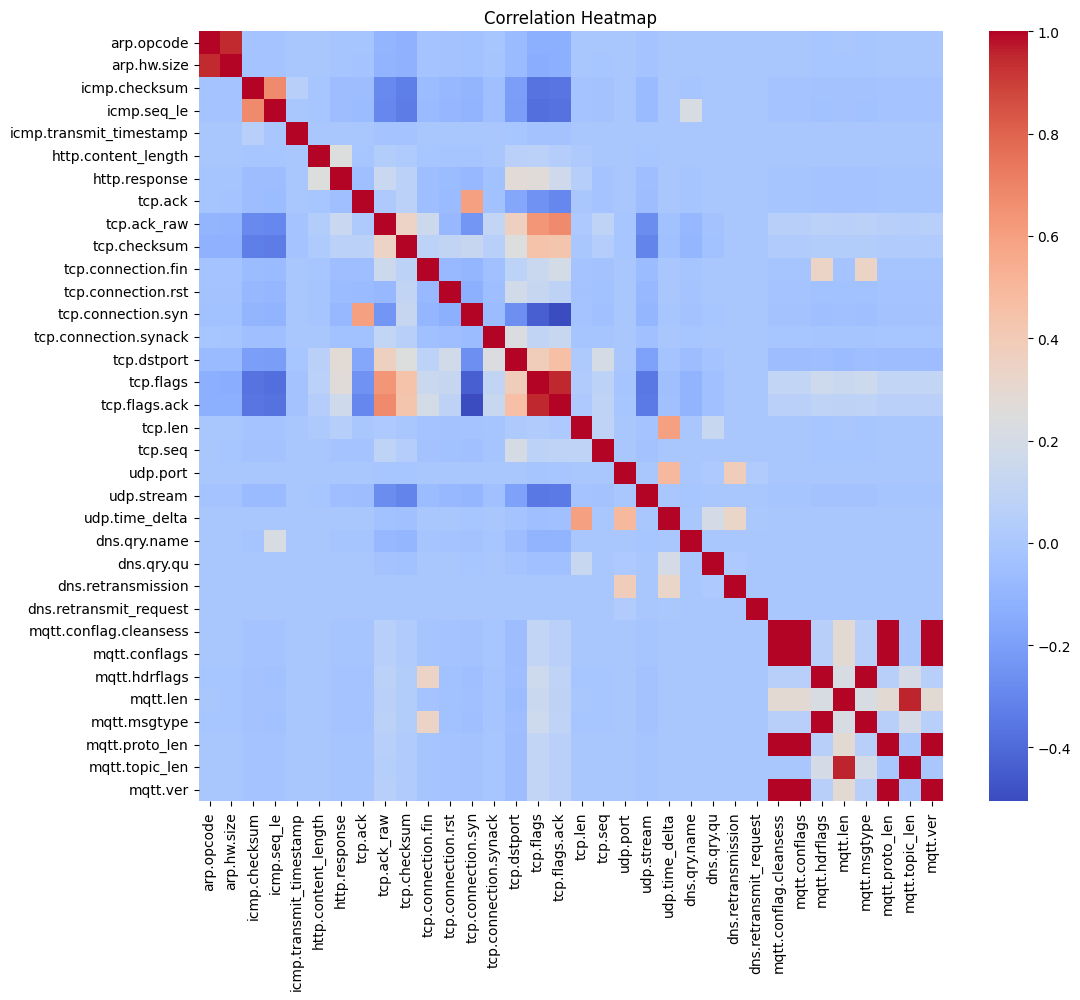

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

X_num = X_train.select_dtypes(include=["int64", "float64"])
X_test_num = X_test.select_dtypes(include=["int64", "float64"])


plt.figure(figsize=(12, 10))
sns.heatmap(X_num.corr(), cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

In [2]:
import numpy as np

corr_matrix = X_num.corr().abs()

# prendiamo solo la parte superiore (evita duplicati)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# soglia
threshold = 1 #decidiamo la soglia di ridondanza tra features

# colonne da eliminare
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Feature rimosse per alta correlazione:")
print(to_drop)

# Applichiamo la selezione
X_train_reduced = X_num.drop(columns=to_drop)
X_test_reduced = X_test_num.drop(columns=to_drop)

print("Originale:")
print("X_train:", X_train.shape)

print("\nDopo rimozione feature non numeriche e correlate:")
print("X_train_reduced:", X_train_reduced.shape)

NameError: name 'X_num' is not defined

### Applichiamo GNB (Gaussian Naive Bayes)

In [14]:
import numpy as np
from scipy.stats import norm

class GaussianNaiveBayes:
    """
    Implementazione del Naive Bayes Gaussiano per caratteristiche continue.
    
    Il Naive Bayes Gaussiano assume che le feature continue seguano una 
    distribuzione normale (gaussiana) all'interno di ogni classe.
    
    Parametri:
    ----------
    var_smoothing : float, default=1e-9
        Valore aggiunto alle varianze per evitare divisioni per zero.
    """
    
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.class_priors = {}  # Probabilità a priori delle classi
        self.means = {}         # Media per ogni feature per ogni classe
        self.variances = {}     # Varianza per ogni feature per ogni classe
        self.classes = None     # Classi possibili
        self.n_features = None  # Numero di feature
        
    def fit(self, X, y):
        """
        Addestra il classificatore Naive Bayes Gaussiano.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        y : array-like, shape (n_samples,)
            Vettore delle classi.
        
        Returns:
        --------
        self : object
        """
        X = np.asarray(X)
        y = np.asarray(y)
        
        n_samples, self.n_features = X.shape
        self.classes = np.unique(y)
        
        # Calcolo delle probabilità a priori delle classi P(y=l)
        for c in self.classes:
            self.class_priors[c] = np.mean(y == c)
            self.means[c] = {}
            self.variances[c] = {}
            
            # Calcolo media e varianza per ogni feature per questa classe
            X_c = X[y == c]
            
            for feature_idx in range(self.n_features):
                feature_values = X_c[:, feature_idx]
                
                # Calcolo media
                self.means[c][feature_idx] = np.mean(feature_values)
                
                # Calcolo varianza (con smoothing)
                self.variances[c][feature_idx] = np.var(feature_values) + self.var_smoothing
        
        return self
    
    def _calculate_gaussian_log_probability(self, x, mean, variance):
        """
        Calcola la densità di probabilità gaussiana.
        
        Parametri:
        ----------
        x : float
            Valore di cui calcolare la probabilità.
        mean : float
            Media della distribuzione gaussiana.
        variance : float
            Varianza della distribuzione gaussiana.
        
        Returns:
        --------
        float : Densità di probabilità calcolata.
        """
        return -0.5 * np.log(2 * np.pi * variance) - ((x - mean) ** 2) / (2 * variance)

    def predict_log_proba(self, X):
        """
        Calcola il logaritmo delle probabilità per ciascuna classe. 
        <- per evitare che la produttoria di probabilità porti ad underflow
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples, n_classes) : Log-probabilità per ogni classe.
        """
        X = np.asarray(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))
        
        for i in range(n_samples):
            for j, c in enumerate(self.classes):
                # Probabilità a priori (in log-spazio)
                log_prob = np.log(self.class_priors[c])
                
                # Somma dei logaritmi delle probabilità condizionate
                for feature_idx in range(self.n_features):
                    x_value = X[i, feature_idx]
                    mean = self.means[c][feature_idx]
                    variance = self.variances[c][feature_idx]
                    log_prob += self._calculate_gaussian_log_probability(
                        x_value, mean, variance)    
                
                log_probs[i, j] = log_prob
        
        return log_probs
    
    def predict_proba(self, X):
        """
        Restituisce le probabilità normalizzate delle classi.
        NON è necessaria, perchè ci interessa il massimo nel numeratore (predict_log_proba), 
        ma può essere utile per interpretabilità:
          ci da le probabilità vere
          posso applicare soglie (è spam solo se P>0.9)
          posso applicare metriche avanzate (tipo ROC)
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples, n_classes) : Probabilità per ogni classe.
        """
        log_probs = self.predict_log_proba(X)
        
        # Normalizzazione numericamente stabile (log-sum-exp trick)
        log_prob_max = np.max(log_probs, axis=1).reshape(-1, 1)
        probs = np.exp(log_probs - log_prob_max)
        probs_sum = np.sum(probs, axis=1).reshape(-1, 1)
        
        return probs / probs_sum
    
    def predict(self, X):
        """
        Predice le classi per i campioni in X.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples,) : Le classi predette.
        """
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]
    
    def score(self, X, y):
        """
        Calcola l'accuratezza del classificatore.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue di test.
        y : array-like, shape (n_samples,)
            Classi vere dei campioni di test.
        
        Returns:
        --------
        float : Accuratezza del classificatore.
        """
        return np.mean(self.predict(X) == y)

Accuracy score: 0.46752217997465145


c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-

                       precision    recall  f1-score   support

             Backdoor       0.33      0.38      0.35      2039
            DDoS_HTTP       0.00      0.00      0.00      2112
            DDoS_ICMP       0.82      1.00      0.90      2818
             DDoS_TCP       0.29      0.89      0.44      2050
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       1.00      0.37      0.54       243
               Normal       1.00      0.36      0.52      4860
             Password       0.00      0.00      0.00      1998
        Port_Scanning       0.37      0.96      0.53      2014
           Ransomware       0.09      0.19      0.12      2185
        SQL_injection       0.27      0.35      0.30      2062
            Uploading       0.00      0.00      0.00      2054
Vulnerability_scanner       0.84      0.76      0.80      2015
                  XSS       0.00      0.00      0.00  

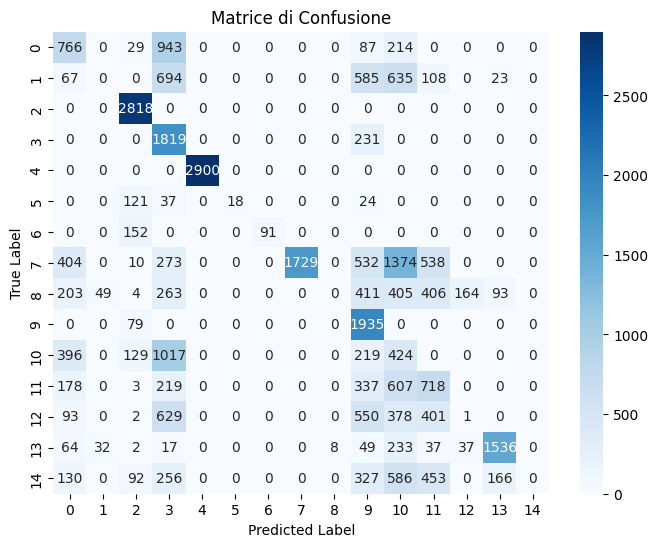

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

SMOOTHING = GaussianNB().var_smoothing

# Creiamo e addestriamo il modello
nb_classifier = GaussianNaiveBayes()
nb_classifier.fit(X_train_reduced, y_train)

# Facciamo predizioni
y_pred_manual = nb_classifier.predict(X_test_reduced)

# Valutiamo le performance
print("Accuracy score:", nb_classifier.score(X_test_reduced, y_test))
print(classification_report(y_test, y_pred_manual))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_manual)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Analizziamo i warning

UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

Il warning indica che almeno una classe presente nel test set **non è mai stata predetta** dal modello.

In questo caso la **precision** per quella classe non può essere calcolata, perché:
$$
Precision = \frac{TP}{TP + FP}
$$
se il modello non predice mai quella classe, allora \(TP + FP = 0\).

Questo non è un errore del codice: segnala che il modello sta ignorando alcune classi.

Accuracy: 0.3923637515842839
                       precision    recall  f1-score   support

             Backdoor       0.70      0.61      0.65      2039
            DDoS_HTTP       0.09      0.24      0.13      2112
            DDoS_ICMP       0.42      1.00      0.60      2818
             DDoS_TCP       0.57      0.33      0.42      2050
             DDoS_UDP       1.00      0.95      0.97      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       0.00      0.00      0.00       243
               Normal       1.00      0.14      0.25      4860
             Password       0.08      0.07      0.08      1998
        Port_Scanning       0.40      0.18      0.25      2014
           Ransomware       0.65      0.42      0.51      2185
        SQL_injection       0.17      0.60      0.27      2062
            Uploading       0.12      0.00      0.01      2054
Vulnerability_scanner       0.72      0.47      0.57      2015
                  XSS    

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-

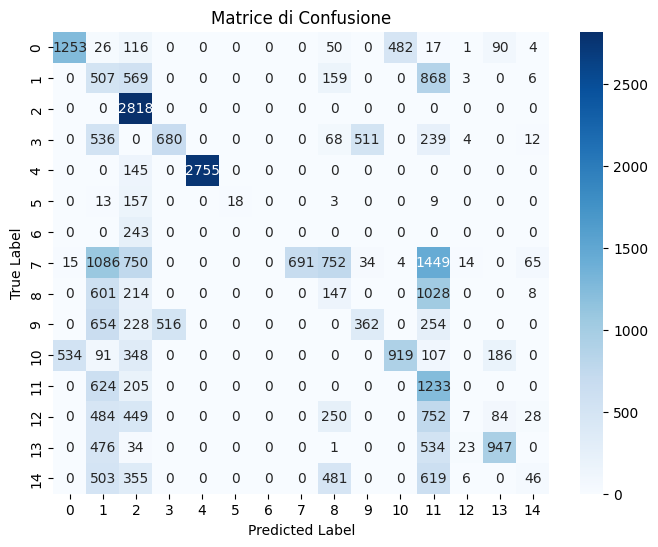

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model = GaussianNB()
model.fit(X_train_reduced, y_train)

y_pred_sklearn = model.predict(X_test_reduced)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
print(classification_report(y_test, y_pred_sklearn))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Le due implementazioni non sono perfettamente equivalenti perché sklearn applica una gestione interna della stabilità numerica diversa dal semplice $1e^{-9}$

## Secondo esperimento: includere feature categoriche codificate

Nel primo esperimento abbiamo usato solo le feature numeriche, perché sono quelle più coerenti con l’ipotesi di Gaussian Naive Bayes.

Tuttavia, il dataset contiene anche molte feature non numeriche. Ignorarle può far perdere informazione utile.

In questo secondo esperimento proviamo quindi a includere anche alcune feature categoriche, trasformandole in valori numerici tramite codifica.

One-hot OPPURE Label encoding?

Con label encoding stiamo assumendo che una categoria abbia un ordine naturale. Per esempio, assegnare:

GET  -> 0
POST -> 1
PUT  -> 2

non implica che POST sia “maggiore” di GET. 

Meglio applicare one-hot encoding.

L’obiettivo di questo esperimento non è ottenere necessariamente il modello più corretto, ma osservare cosa succede quando includiamo feature categoriche codificate e discutere i limiti metodologici di questa scelta.

In [17]:
from sklearn.preprocessing import OneHotEncoder

# selezione feature categoriche
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns

cardinality = X_train[categorical_features].nunique().sort_values(ascending=False)

print(cardinality)
print("Numero totale colonne one-hot attese:", cardinality.sum())

# dataset misti:
# numeriche selezionate + categoriche
'''
X_train_mix = pd.concat(
    [X_train_reduced, X_train[categorical_features].astype(str)],
    axis=1
)

X_test_mix = pd.concat(
    [X_test_reduced, X_test[categorical_features].astype(str)],
    axis=1
)

# one-hot encoding SOLO sulle categoriche
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = ohe.fit_transform(
    X_train_mix[categorical_features]
)

X_test_cat = ohe.transform(
    X_test_mix[categorical_features]
)

# dataframe one-hot
X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=ohe.get_feature_names_out(categorical_features),
    index=X_train_mix.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=ohe.get_feature_names_out(categorical_features),
    index=X_test_mix.index
)

# dataset finale:
# numeriche + categoriche codificate
X_train_final = pd.concat(
    [X_train_reduced, X_train_cat_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_reduced, X_test_cat_df],
    axis=1
)
'''

frame.time                124152
tcp.options                59006
tcp.srcport                28272
tcp.payload                21947
ip.src_host                15281
ip.dst_host                 6459
http.request.full_uri       3374
http.request.uri.query      1398
http.file_data               401
mqtt.msg                     115
arp.src.proto_ipv4             8
dns.qry.name.len               8
arp.dst.proto_ipv4             8
http.request.version           8
http.request.method            6
http.referer                   4
mqtt.conack.flags              3
mqtt.protoname                 3
mqtt.topic                     3
dtype: int64
Numero totale colonne one-hot attese: 260456


'\nX_train_mix = pd.concat(\n    [X_train_reduced, X_train[categorical_features].astype(str)],\n    axis=1\n)\n\nX_test_mix = pd.concat(\n    [X_test_reduced, X_test[categorical_features].astype(str)],\n    axis=1\n)\n\n# one-hot encoding SOLO sulle categoriche\nohe = OneHotEncoder(\n    handle_unknown="ignore",\n    sparse_output=False\n)\n\nX_train_cat = ohe.fit_transform(\n    X_train_mix[categorical_features]\n)\n\nX_test_cat = ohe.transform(\n    X_test_mix[categorical_features]\n)\n\n# dataframe one-hot\nX_train_cat_df = pd.DataFrame(\n    X_train_cat,\n    columns=ohe.get_feature_names_out(categorical_features),\n    index=X_train_mix.index\n)\n\nX_test_cat_df = pd.DataFrame(\n    X_test_cat,\n    columns=ohe.get_feature_names_out(categorical_features),\n    index=X_test_mix.index\n)\n\n# dataset finale:\n# numeriche + categoriche codificate\nX_train_final = pd.concat(\n    [X_train_reduced, X_train_cat_df],\n    axis=1\n)\n\nX_test_final = pd.concat(\n    [X_test_reduced, X_tes

# One hot encoding

creerebbe una matrice di 261.594 colonne e darebbe memory error (provare per credere).

Per mantenere l'esperimento semplice e compatibile con GaussianNB, usiamo Label Encoding come compromesso pratico, pur riconoscendone i limiti metodologici.

In [18]:
from sklearn.preprocessing import LabelEncoder

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns

# numeriche selezionate + categoriche codificate
X_train_le = X_train_reduced.copy()
X_test_le = X_test_reduced.copy()

encoders = {}

for col in categorical_features:
    le = LabelEncoder()

    # fit SOLO sul training set
    X_train_le[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    # mapping categorie -> interi
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))

    # transform del test set
    X_test_le[col] = X_test[col].astype(str).map(mapping)

    # categorie mai viste nel training
    X_test_le[col] = X_test_le[col].fillna(-1)

    encoders[col] = le

### Riapplichiamo GNB manuale e con scikit-learn

Accuracy score: 0.3496831432192649
                       precision    recall  f1-score   support

             Backdoor       0.68      0.65      0.66      2039
            DDoS_HTTP       0.10      0.73      0.17      2112
            DDoS_ICMP       0.42      1.00      0.60      2818
             DDoS_TCP       0.61      0.19      0.29      2050
             DDoS_UDP       1.00      0.95      0.97      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       0.00      0.00      0.00       243
               Normal       1.00      0.14      0.25      4860
             Password       0.00      0.00      0.00      1998
        Port_Scanning       0.43      0.32      0.36      2014
           Ransomware       0.67      0.39      0.50      2185
        SQL_injection       0.00      0.00      0.00      2062
            Uploading       0.00      0.00      0.00      2054
Vulnerability_scanner       0.22      0.01      0.03      2015
                  X

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-

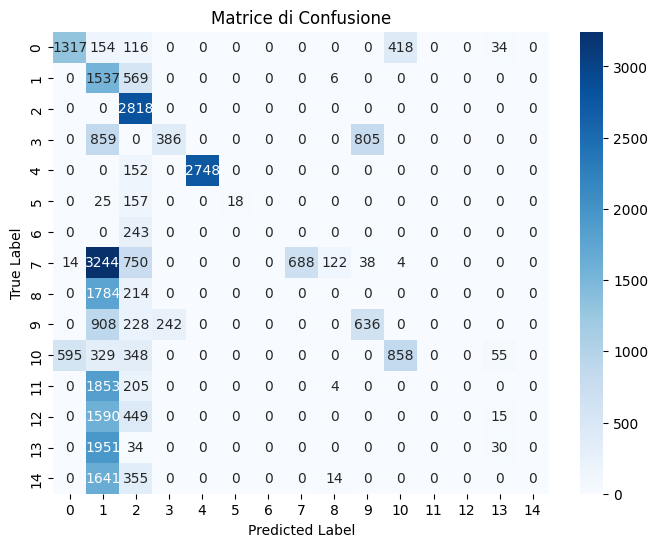

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Creiamo e addestriamo il modello
nb_classifier = GaussianNaiveBayes(var_smoothing=SMOOTHING)
nb_classifier.fit(X_train_le, y_train)

# Facciamo predizioni
y_pred_manual = nb_classifier.predict(X_test_le)

# Valutiamo le performance
print("Accuracy score:", nb_classifier.score(X_test_le, y_test))
print(classification_report(y_test, y_pred_manual))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_manual)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Abbiamo ancora il problema del warning

Il warning indica che almeno una classe presente nel test set **non è mai stata predetta** dal modello.

### INOLTRE

l'accuratezza del modello è leggermente peggiorata


Accuracy: 0.3496831432192649
                       precision    recall  f1-score   support

             Backdoor       0.68      0.65      0.66      2039
            DDoS_HTTP       0.10      0.73      0.17      2112
            DDoS_ICMP       0.42      1.00      0.60      2818
             DDoS_TCP       0.61      0.19      0.29      2050
             DDoS_UDP       1.00      0.95      0.97      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       0.00      0.00      0.00       243
               Normal       1.00      0.14      0.25      4860
             Password       0.00      0.00      0.00      1998
        Port_Scanning       0.43      0.32      0.36      2014
           Ransomware       0.67      0.39      0.50      2185
        SQL_injection       0.00      0.00      0.00      2062
            Uploading       0.00      0.00      0.00      2054
Vulnerability_scanner       0.22      0.01      0.03      2015
                  XSS    

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-

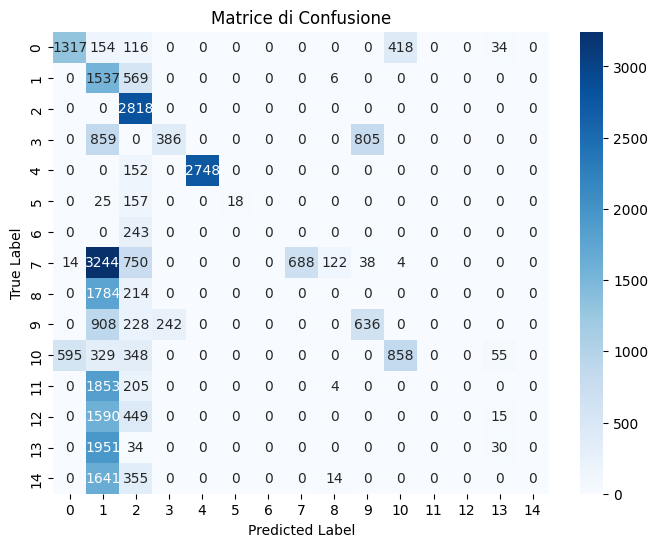

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model = GaussianNB()
model.fit(X_train_le, y_train)

y_pred_sklearn = model.predict(X_test_le)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
print(classification_report(y_test, y_pred_sklearn))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Fino a questo punto abbiamo lavorato principalmente sulle feature e sulle assunzioni del modello. Tuttavia, nel caso di Naive Bayes esiste un altro aspetto molto importante: le probabilità a priori delle classi.

## Analisi dello sbilanciamento delle classi

Se il dataset è fortemente sbilanciato, il classificatore può tendere a favorire la classe più frequente, ottenendo anche un’accuracy apparentemente elevata ma prestazioni molto scarse sulle classi minoritarie.

Per questo motivo è importante analizzare la distribuzione delle classi prima di interpretare i risultati del modello.

In questa fase proveremo quindi alcune tecniche di bilanciamento del training set. 
##### Il bilanciamento risolve il problema della P(classe) ma non di P(feature|classe):

- oversampling della classe minoritaria;
- undersampling della classe maggioritaria.

Il bilanciamento deve essere applicato **solo sul training set**.

Applicarlo prima dello split train/test costituirebbe infatti una forma di data leakage, perché informazioni sintetiche o duplicate del training potrebbero finire indirettamente anche nel test set, alterando la valutazione finale del modello.

Il test set deve invece rimanere invariato, così da rappresentare una stima realistica delle prestazioni su dati mai visti.

In [21]:
#Studiamo le labels
print(y_train.value_counts())
print("Number of unique labels:", df['Attack_type'].nunique())


Attack_type
Normal                   19441
DDoS_UDP                 11598
DDoS_ICMP                11272
Ransomware                8740
DDoS_HTTP                 8449
SQL_injection             8249
Uploading                 8215
DDoS_TCP                  8197
Backdoor                  8156
Vulnerability_scanner     8061
Port_Scanning             8057
XSS                       8042
Password                  7991
MITM                       971
Fingerprinting             801
Name: count, dtype: int64
Number of unique labels: 15


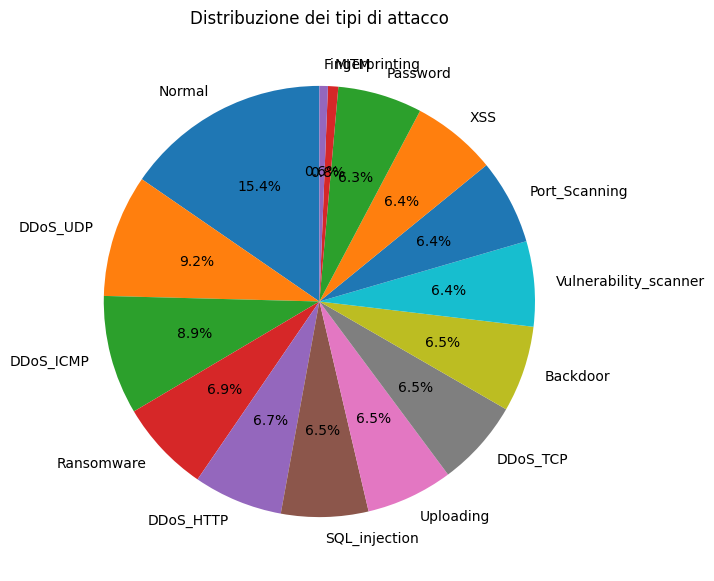

In [22]:
import matplotlib.pyplot as plt

# Contare i valori nella colonna 'Attack_type'
attack_counts = y_train.value_counts()

# Creiamo un dataframe temporaneo SOLO con il training set
train_df = X_train_le.copy()
train_df["Attack_type"] = y_train

# Creare un grafico a torta
plt.figure(figsize=(10, 7))  # Imposta le dimensioni della figura
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuzione dei tipi di attacco')
plt.show()

### Sovracampionamento delle classi minoritarie (oversampling)

In [23]:
from sklearn.utils import resample

# OVERSAMPLING SOLO SUL TRAINING SET

class_counts = train_df["Attack_type"].value_counts()
print("Distribuzione originale del training set:")
print(class_counts)

max_samples = class_counts.max()
balanced_dfs = []

for attack_type in train_df["Attack_type"].unique():
    class_df = train_df[train_df["Attack_type"] == attack_type]
    
    if len(class_df) < max_samples:
        class_df = resample(
            class_df,
            replace=True,
            n_samples=max_samples,
            random_state=42
        )
    
    balanced_dfs.append(class_df)

train_df_over = pd.concat(balanced_dfs)

X_train_over = train_df_over.drop(columns=["Attack_type"])
y_train_over = train_df_over["Attack_type"]

print("\nDistribuzione dopo oversampling:")
print(y_train_over.value_counts())

print("\nDimensione originale training set:", len(train_df))
print("Dimensione dopo oversampling:", len(train_df_over))

Distribuzione originale del training set:
Attack_type
Normal                   19441
DDoS_UDP                 11598
DDoS_ICMP                11272
Ransomware                8740
DDoS_HTTP                 8449
SQL_injection             8249
Uploading                 8215
DDoS_TCP                  8197
Backdoor                  8156
Vulnerability_scanner     8061
Port_Scanning             8057
XSS                       8042
Password                  7991
MITM                       971
Fingerprinting             801
Name: count, dtype: int64

Distribuzione dopo oversampling:
Attack_type
Ransomware               19441
Port_Scanning            19441
Backdoor                 19441
Fingerprinting           19441
DDoS_ICMP                19441
Uploading                19441
SQL_injection            19441
Password                 19441
XSS                      19441
Normal                   19441
DDoS_TCP                 19441
Vulnerability_scanner    19441
DDoS_HTTP                19441
DDoS_U

### Riduzione delle classi maggioritarie (undersampling)

In [24]:
from sklearn.utils import resample

# UNDERSAMPLING SOLO SUL TRAINING SET

class_counts = train_df["Attack_type"].value_counts()
print("Distribuzione originale del training set:")
print(class_counts)

min_samples = class_counts.min()
balanced_dfs = []

for attack_type in train_df["Attack_type"].unique():
    class_df = train_df[train_df["Attack_type"] == attack_type]
    
    if len(class_df) > min_samples:
        class_df = resample(
            class_df,
            replace=False,
            n_samples=min_samples,
            random_state=42
        )
    
    balanced_dfs.append(class_df)

train_df_under = pd.concat(balanced_dfs)

X_train_under = train_df_under.drop(columns=["Attack_type"])
y_train_under = train_df_under["Attack_type"]

print("\nDistribuzione dopo undersampling:")
print(y_train_under.value_counts())

print("\nDimensione originale training set:", len(train_df))
print("Dimensione dopo undersampling:", len(train_df_under))

Distribuzione originale del training set:
Attack_type
Normal                   19441
DDoS_UDP                 11598
DDoS_ICMP                11272
Ransomware                8740
DDoS_HTTP                 8449
SQL_injection             8249
Uploading                 8215
DDoS_TCP                  8197
Backdoor                  8156
Vulnerability_scanner     8061
Port_Scanning             8057
XSS                       8042
Password                  7991
MITM                       971
Fingerprinting             801
Name: count, dtype: int64

Distribuzione dopo undersampling:
Attack_type
Ransomware               801
Port_Scanning            801
Backdoor                 801
Fingerprinting           801
DDoS_ICMP                801
Uploading                801
SQL_injection            801
Password                 801
XSS                      801
Normal                   801
DDoS_TCP                 801
Vulnerability_scanner    801
DDoS_HTTP                801
DDoS_UDP                 801
MI

###Approccio Ibrido

Undersampling delle classi più numerose

Oversampling delle classi meno numerose

Distribuzione originale del training set:
Attack_type
Normal                   19441
DDoS_UDP                 11598
DDoS_ICMP                11272
Ransomware                8740
DDoS_HTTP                 8449
SQL_injection             8249
Uploading                 8215
DDoS_TCP                  8197
Backdoor                  8156
Vulnerability_scanner     8061
Port_Scanning             8057
XSS                       8042
Password                  7991
MITM                       971
Fingerprinting             801
Name: count, dtype: int64

Target desiderato per classe: 10000

Distribuzione dopo balancing ibrido:
Attack_type
Ransomware               10000
Port_Scanning            10000
Backdoor                 10000
Fingerprinting           10000
DDoS_ICMP                10000
Uploading                10000
SQL_injection            10000
Password                 10000
XSS                      10000
Normal                   10000
DDoS_TCP                 10000
Vulnerability_scanner    10

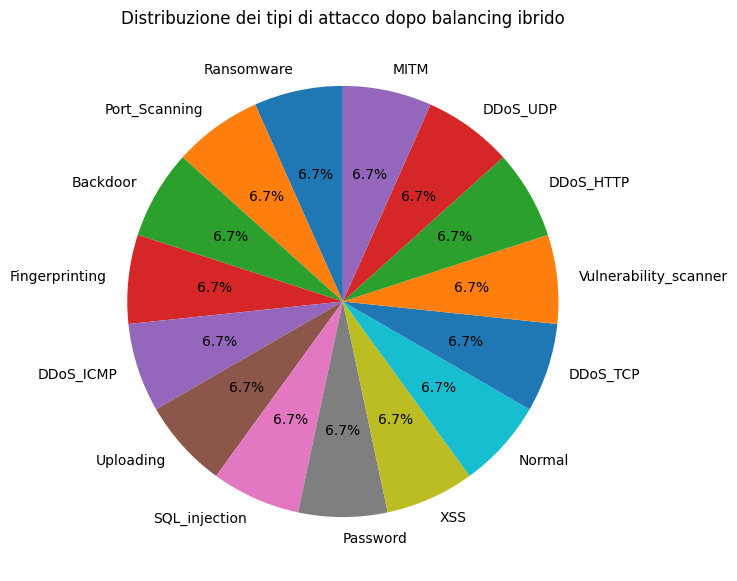


Dimensione originale training set: 126240
Dimensione dopo balancing ibrido: 150000


In [25]:
from sklearn.utils import resample
import pandas as pd
import matplotlib.pyplot as plt

# Target desiderato: numero di campioni per classe
target_samples = 10000

# Otteniamo le frequenze di ogni classe
class_counts = train_df["Attack_type"].value_counts()

print("Distribuzione originale del training set:")
print(class_counts)

print(f"\nTarget desiderato per classe: {target_samples}")

balanced_dfs = []

# Per ogni classe, applichiamo oversampling o undersampling verso il target
for attack_type in train_df["Attack_type"].unique():
    class_df = train_df[train_df["Attack_type"] == attack_type]
    n_samples = len(class_df)
    
    if n_samples < target_samples:
        class_df = resample(
            class_df,
            replace=True,
            n_samples=target_samples,
            random_state=42
        )
    
    elif n_samples > target_samples:
        class_df = resample(
            class_df,
            replace=False,
            n_samples=target_samples,
            random_state=42
        )
    
    balanced_dfs.append(class_df)

# Combiniamo tutti i DataFrame bilanciati
train_df_hybrid = pd.concat(balanced_dfs)

X_train_hybrid = train_df_hybrid.drop(columns=["Attack_type"])
y_train_hybrid = train_df_hybrid["Attack_type"]

# Verifichiamo la nuova distribuzione
print("\nDistribuzione dopo balancing ibrido:")
print(y_train_hybrid.value_counts())

# Visualizziamo la nuova distribuzione con un grafico a torta
plt.figure(figsize=(10, 7))
attack_counts_balanced = train_df_hybrid["Attack_type"].value_counts()
plt.pie(
    attack_counts_balanced,
    labels=attack_counts_balanced.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribuzione dei tipi di attacco dopo balancing ibrido')
plt.show()

print("\nDimensione originale training set:", len(train_df))
print("Dimensione dopo balancing ibrido:", len(train_df_hybrid))

### Vantaggi e Svantaggi
##### Undersampling
- Pro:
  - Minor costo computazionale;
  - Evita problemi di memoria;
  - Riduce il tempo di training.

- Contro:
  - Perdita di informazioni potenzialmente utili;
  - Rischio di sottorappresentare la variabilità della classe maggioritaria.
##### Oversampling
- Pro:
  - Mantiene tutte le informazioni originali;
  - Non perde esempi potenzialmente importanti.

- Contro:
  - Rischio di overfitting sulle classi minoritarie;
  - Maggior costo computazionale;
  - Può creare copie identiche dei dati.
##### Approccio Ibrido
- Pro:
  - Compromesso tra perdita di dati e crescita del dataset;
  - Riduce il rischio di dataset troppo grandi;
  - Mantiene una quantità più equilibrata di informazioni per classe;
  - Spesso più pratico su dataset molto grandi.

- Contro:
  - Introduce sia duplicazione di campioni sia rimozione di dati;
  - Richiede la scelta di un target di campioni per classe;
  - Il target scelto può influenzare significativamente i risultati.
##### La scelta dipende da:
   Dimensione del dataset originale

   Sbilanciamento delle classi

   Risorse computazionali disponibili
   
   Importanza relativa di falsi positivi vs falsi negativi


## Training & Prediction

### Importiamo Bayes

### Applichiamo inizialmente l'undersampling che sembra più promettente

Accuratezza del modello: 0.3568


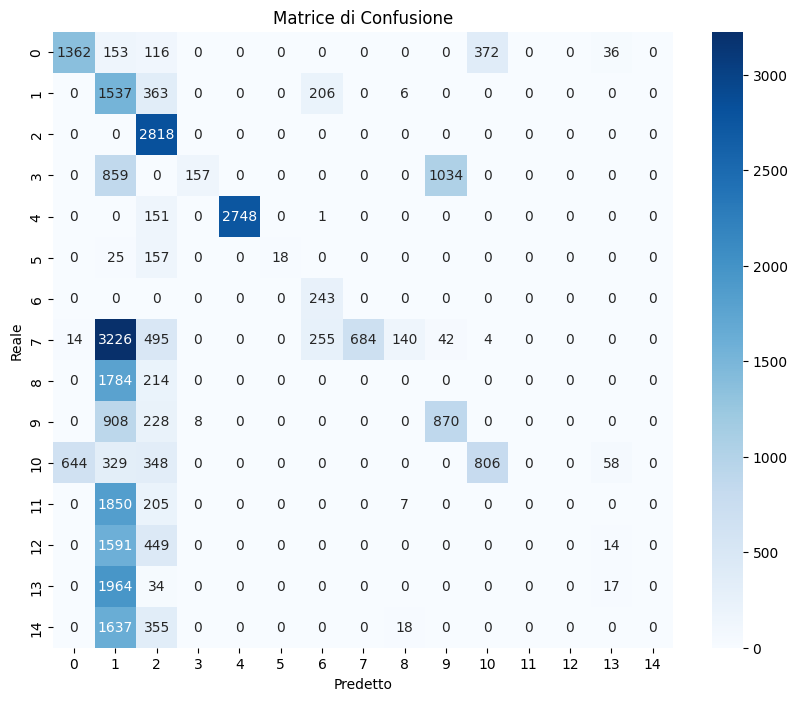


Report di classificazione:
                       precision    recall  f1-score   support

             Backdoor       0.67      0.67      0.67      2039
            DDoS_HTTP       0.10      0.73      0.17      2112
            DDoS_ICMP       0.47      1.00      0.64      2818
             DDoS_TCP       0.95      0.08      0.14      2050
             DDoS_UDP       1.00      0.95      0.97      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       0.34      1.00      0.51       243
               Normal       1.00      0.14      0.25      4860
             Password       0.00      0.00      0.00      1998
        Port_Scanning       0.45      0.43      0.44      2014
           Ransomware       0.68      0.37      0.48      2185
        SQL_injection       0.00      0.00      0.00      2062
            Uploading       0.00      0.00      0.00      2054
Vulnerability_scanner       0.14      0.01      0.02      2015
                  XSS     

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-

In [ ]:
# Creiamo e addestriamo il modello
gnb = GaussianNaiveBayes(var_smoothing=SMOOTHING)
gnb.fit(X_train_under, y_train_under)

# Facciamo le predizioni
y_pred = gnb.predict(X_test_le)

# Calcoliamo l'accuratezza
accuracy = gnb.score(X_test_le, y_test)
print(f"Accuratezza del modello: {accuracy:.4f}")

# Visualizziamo la matrice di confusione
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Creiamo la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Visualizziamo la matrice di confusione con seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

# Stampiamo il report di classificazione
print("\nReport di classificazione:")
print(classification_report(y_test, y_pred))


### Proviamo ad applicare l'oversampling

ATTENZIONE: Nel caso di GaussianNB, Random Oversampling tende a modificare poco le distribuzioni gaussiane stimate, perché introduce principalmente duplicati dei campioni esistenti (quindi con media e varianza uguali).

Accuratezza del modello: 0.3571


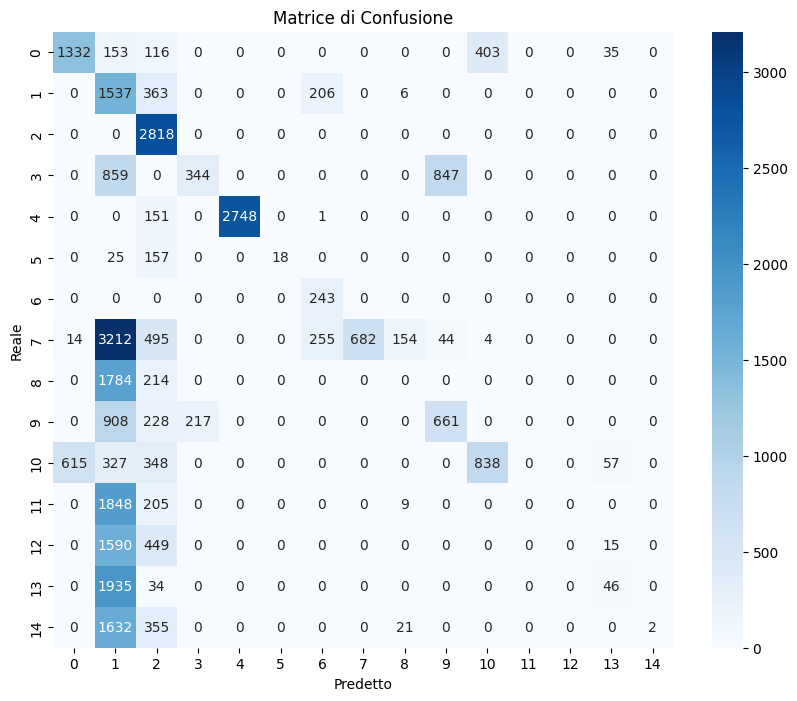


Report di classificazione:


c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                       precision    recall  f1-score   support

             Backdoor       0.68      0.65      0.67      2039
            DDoS_HTTP       0.10      0.73      0.17      2112
            DDoS_ICMP       0.47      1.00      0.64      2818
             DDoS_TCP       0.61      0.17      0.26      2050
             DDoS_UDP       1.00      0.95      0.97      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       0.34      1.00      0.51       243
               Normal       1.00      0.14      0.25      4860
             Password       0.00      0.00      0.00      1998
        Port_Scanning       0.43      0.33      0.37      2014
           Ransomware       0.67      0.38      0.49      2185
        SQL_injection       0.00      0.00      0.00      2062
            Uploading       0.00      0.00      0.00      2054
Vulnerability_scanner       0.30      0.02      0.04      2015
                  XSS       1.00      0.00      0.00  

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Creiamo e addestriamo il modello
gnb = GaussianNaiveBayes(var_smoothing=SMOOTHING)
gnb.fit(X_train_over, y_train_over)

# Facciamo le predizioni
y_pred = gnb.predict(X_test_le)

# Calcoliamo l'accuratezza
accuracy = gnb.score(X_test_le, y_test)
print(f"Accuratezza del modello: {accuracy:.4f}")

# Visualizziamo la matrice di confusione
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Creiamo la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Visualizziamo la matrice di confusione con seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

# Stampiamo il report di classificazione
print("\nReport di classificazione:")
print(classification_report(y_test, y_pred))


### Proviamo la versione ibrida

Accuratezza del modello: 0.3575


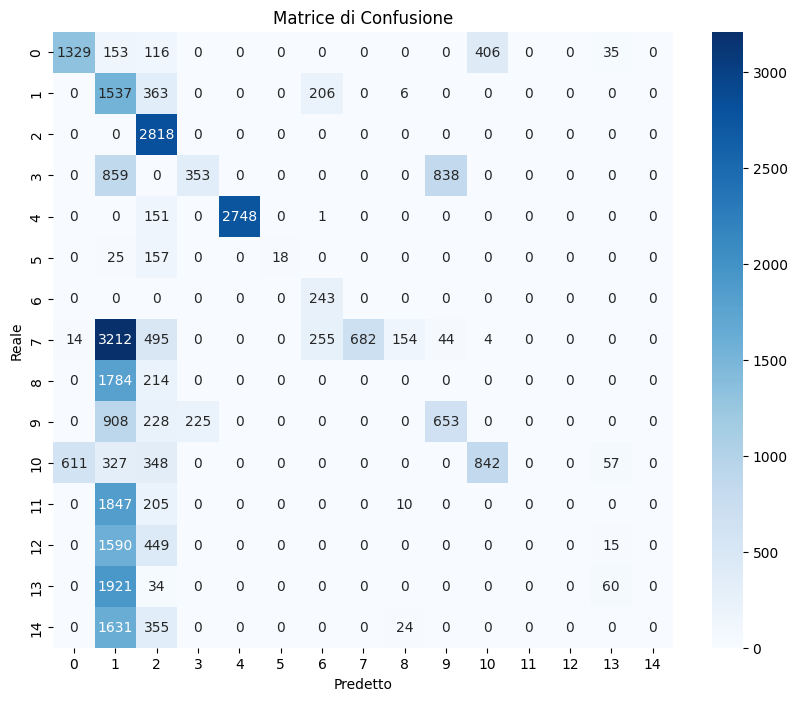


Report di classificazione:
                       precision    recall  f1-score   support

             Backdoor       0.68      0.65      0.67      2039
            DDoS_HTTP       0.10      0.73      0.17      2112
            DDoS_ICMP       0.47      1.00      0.64      2818
             DDoS_TCP       0.61      0.17      0.27      2050
             DDoS_UDP       1.00      0.95      0.97      2900
       Fingerprinting       1.00      0.09      0.17       200
                 MITM       0.34      1.00      0.51       243
               Normal       1.00      0.14      0.25      4860
             Password       0.00      0.00      0.00      1998
        Port_Scanning       0.43      0.32      0.37      2014
           Ransomware       0.67      0.39      0.49      2185
        SQL_injection       0.00      0.00      0.00      2062
            Uploading       0.00      0.00      0.00      2054
Vulnerability_scanner       0.36      0.03      0.05      2015
                  XSS     

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-

In [ ]:
# Creiamo e addestriamo il modello
gnb = GaussianNaiveBayes(var_smoothing=SMOOTHING)
gnb.fit(X_train_hybrid, y_train_hybrid)

# Facciamo le predizioni
y_pred = gnb.predict(X_test_le)

# Calcoliamo l'accuratezza
accuracy = gnb.score(X_test_le, y_test)
print(f"Accuratezza del modello: {accuracy:.4f}")

# Visualizziamo la matrice di confusione
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Creiamo la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Visualizziamo la matrice di confusione con seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

# Stampiamo il report di classificazione
print("\nReport di classificazione:")
print(classification_report(y_test, y_pred))


##### Scikit sul modello ibrido

Accuratezza del modello sklearn: 0.3571


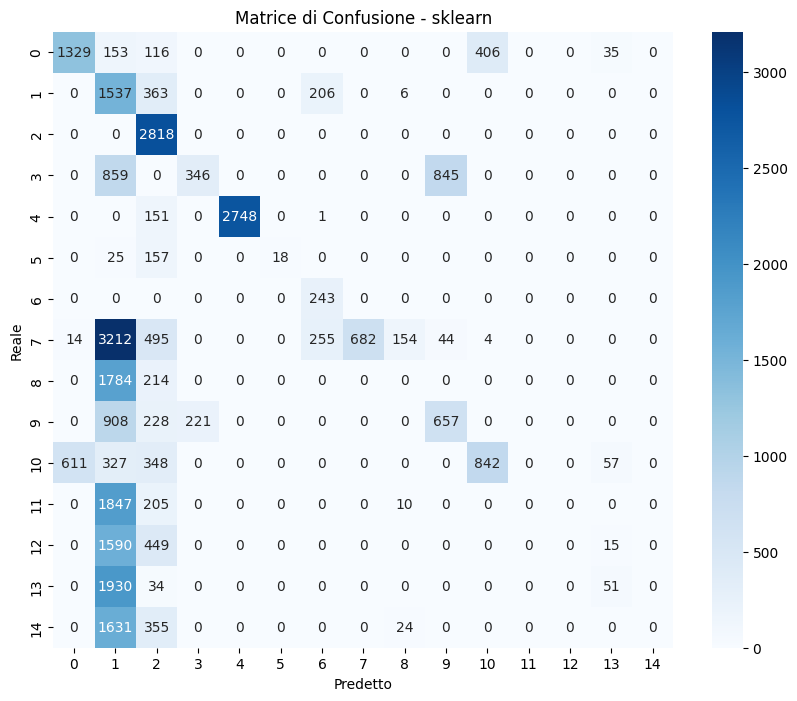

In [29]:
#Usiamo NB da sklearn
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
#chiamiamo il modello
gnb_sklearn = GaussianNB()
#addestriamo il modello
gnb_sklearn.fit(X_train_hybrid, y_train_hybrid)
#facciamo le predizioni
y_pred_sklearn = gnb_sklearn.predict(X_test_le)
#calcoliamo l'accuratezza
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuratezza del modello sklearn: {accuracy_sklearn:.4f}")
# Visualizziamo la matrice di confusione
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
# Visualizziamo la matrice di confusione con seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione - sklearn')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()


##### Il Bilanciamento è servito a qualcosa?

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
import pandas as pd

# Confronto diretto tra tutti gli approcci
configs = {
    "Baseline (sbilanciato)": (X_train_le, y_train),
    "Undersampling":          (X_train_under, y_train_under),
    "Oversampling":           (X_train_over, y_train_over),
    "Ibrido":                 (X_train_hybrid, y_train_hybrid),
}

rows = []
'''
for name, (X_tr, y_tr) in configs.items():
    gnb_tmp = GaussianNaiveBayes(var_smoothing=SMOOTHING)
    gnb_tmp.fit(X_tr, y_tr)
    y_p = gnb_tmp.predict(X_test_le)
    
    rows.append({
        "Scenario":         name,
        "Accuracy":         round((y_p == y_test).mean(), 4),
        "Macro F1":         round(f1_score(y_test, y_p, average="macro", zero_division=0), 4),
        "Classi predette":  len(set(y_p)),
        "Classi nel test":  len(set(y_test)),
    })
'''

for name, (X_tr, y_tr) in configs.items():
    gnb_tmp = GaussianNB()
    gnb_tmp.fit(X_tr, y_tr)
    y_p = gnb_tmp.predict(X_test_le)
    
    rows.append({
        "Scenario":         name,
        "Accuracy":         round((y_p == y_test).mean(), 4),
        "Balanced Accuracy":round(balanced_accuracy_score(y_test, y_p), 4),
        "Macro F1":         round(f1_score(y_test, y_p, average="macro", zero_division=0), 4),
        "Classi predette":  len(set(y_p)),
        "Classi nel test":  len(set(y_test)),
    })

pd.DataFrame(rows).set_index("Scenario")

,Accuracy,Balanced Accuracy,Macro F1,Classi predette,Classi nel test
Scenario,,,,,
Baseline (sbilanciato),0.3497,0.2976,0.2662,11,15
Undersampling,0.3562,0.3634,0.2958,12,15
Oversampling,0.3569,0.3640,0.3026,13,15
Ibrido,0.3571,0.3642,0.3032,12,15


Accuracy (0.35) è costante → metrica ingannevole su dati sbilanciati. Il bilanciamento non la muove perché le classi dominanti pesano troppo.


Macro F1 sale (+14%) e classi predette aumentano (11→13) → il bilanciamento ha fatto qualcosa di reale, ma limitato dal modello.


Il limite non è il preprocessing — è il modello. GNB viola due assunzioni su questo dataset: gaussianità delle feature di rete (falsa) e indipendenza delle feature (falsa, come mostra la heatmap di correlazione). 

Questo è il punto di arrivo naturale: "abbiamo fatto tutto il preprocessing corretto, e i risultati ci dicono che dobbiamo cambiare modello, non continuare a tweakare i dati."

### Confrontiamo i risultati con KNN

Accuracy kNN: 0.7603

Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.95      0.93      0.94      2039
            DDoS_HTTP       0.48      0.62      0.54      2112
            DDoS_ICMP       1.00      0.99      1.00      2818
             DDoS_TCP       0.89      0.87      0.88      2050
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.87      0.68      0.76       200
                 MITM       1.00      0.37      0.54       243
               Normal       0.85      0.90      0.87      4860
             Password       0.32      0.25      0.28      1998
        Port_Scanning       0.85      0.92      0.88      2014
           Ransomware       0.91      0.84      0.88      2185
        SQL_injection       0.50      0.52      0.51      2062
            Uploading       0.54      0.45      0.49      2054
Vulnerability_scanner       0.89      0.79      0.84      2015
         

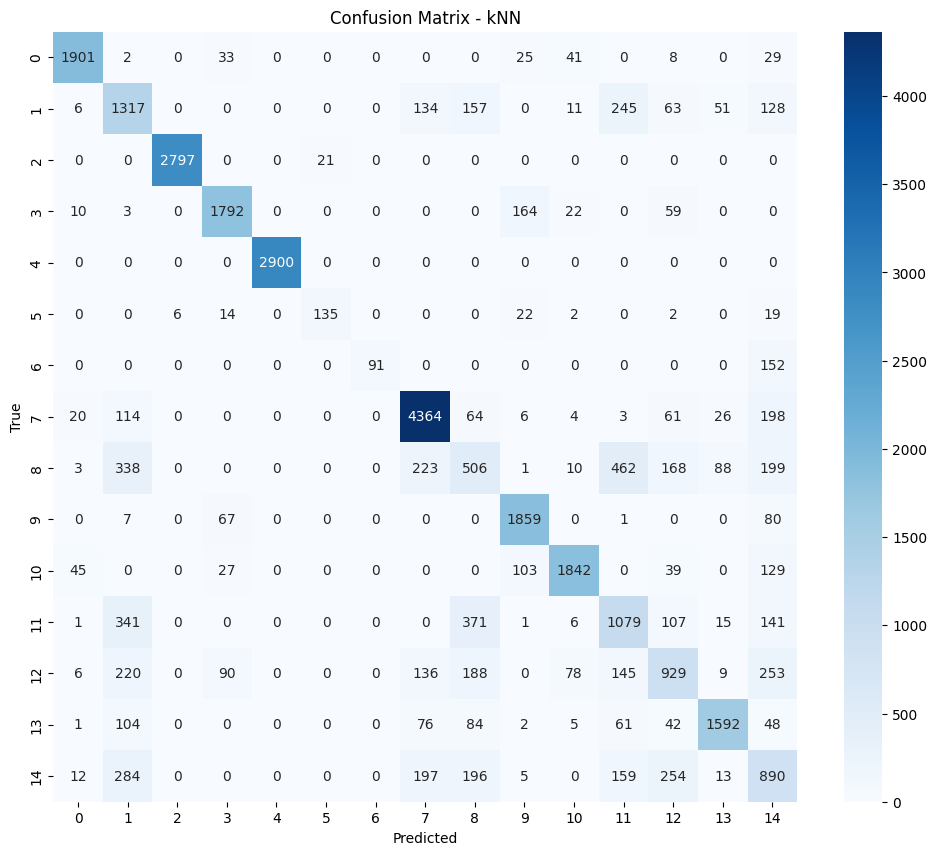

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

# Pipeline: scaling + kNN
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        metric="euclidean"
    ))
])

# Training
knn_model.fit(X_train_reduced, y_train)

# Predizioni
y_pred_knn = knn_model.predict(X_test_reduced)

# Metriche
print(f"Accuracy kNN: {accuracy_score(y_test, y_pred_knn):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Visualizzazione
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - kNN')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

### Il preprocessing può aiutare, ma non sostituisce la compatibilità tra modello e dati.